## Tiền xử lý dữ liệu
Dữ liệu đầu vào gồm các features, đầu tiên cần hiểu rõ các cột này mang ý nghĩa gì:  
-HeartDisease : Có bệnh tim hay không ( cột cần dự đoán)  
**Nhóm chỉ số số học :**  
-BMI : Chỉ số khối cơ thể  
-PhysicalHealth:Số ngày sức khỏe thể chất không tốt trong 30 ngày gần nhất  
-MentalHealth:Số ngày sức khỏe tinh thần không tốt trong 30 ngày gần nhất  
-SleepTime:Số giờ ngủ trung bình mỗi ngày  
**Nhóm biến Yes/No :**  
-Smoking : Có hút thuốc không  
-AlcoholDrinking:Có uống rượu nhiều không  
-Stroke: Có từng bị đột quỵ không  
-DiffWalking: Có khó khăn khi đi bộ không  
-PhysicalActivity: Có hoạt động thể chất không  
-Asthma: Có hen suyễn không  
-KidneyDisease:Có bệnh thận không  
-SkinCancer:Có ung thư da không  
**Nhóm biến phân loại nhiều giá trị :**  
-Sex:Giới tính  
-AgeCategory:Nhóm tuổi  
-Race: Chủng tộc  
-Diabetic: Tình trạng tiểu đường  
-GenHealth:	Tự đánh giá sức khỏe tổng quát  



## Đọc thông tin và mô tả dữ liệu

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. Đọc dữ liệu
df = pd.read_csv("heart_2020_cleaned.csv")
print(f"Kích thước ban đầu: {df.shape}")


# Phân loại cột
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']


Kích thước ban đầu: (319795, 18)


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  str    
 16  KidneyDisease     319795 non-nu

In [83]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


Kiểm tra dữ liệu thiếu 

Dữ liệu thiếu là các ô bị rỗng hoặc có giá trị NaN. Nếu dữ liệu có nhiều giá trị thiếu, ta cần xử lý bằng cách điền trung bình, trung vị, mode hoặc xóa dòng bị thiếu.

In [84]:
#3 : Kiểm tra số lượng giá trị thiếu ở từng cột
missing_values = df.isnull().sum()

print("Số giá trị thiếu theo từng cột:")
print(missing_values)

Số giá trị thiếu theo từng cột:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64


Kiểm tra và xử lý dữ liệu trùng lặp  
Dữ liệu trùng lặp là các dòng có thông tin giống hệt nhau. Nếu giữ lại các dòng trùng lặp, mô hình có thể học lệch vì một số mẫu xuất hiện nhiều lần.

In [85]:
# Xóa dòng trùng lặp
df = df.drop_duplicates()

# Đánh lại index
df = df.reset_index(drop=True)

print("Kích thước sau khi xóa trùng:", df.shape)

Kích thước sau khi xóa trùng: (301717, 18)


## Trực quan hóa các biến số

--- TRỰC QUAN HÓA DỮ LIỆU GỐC ---


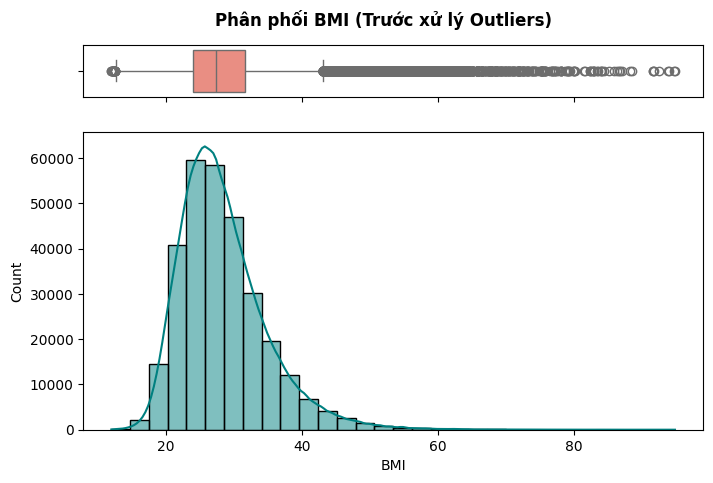

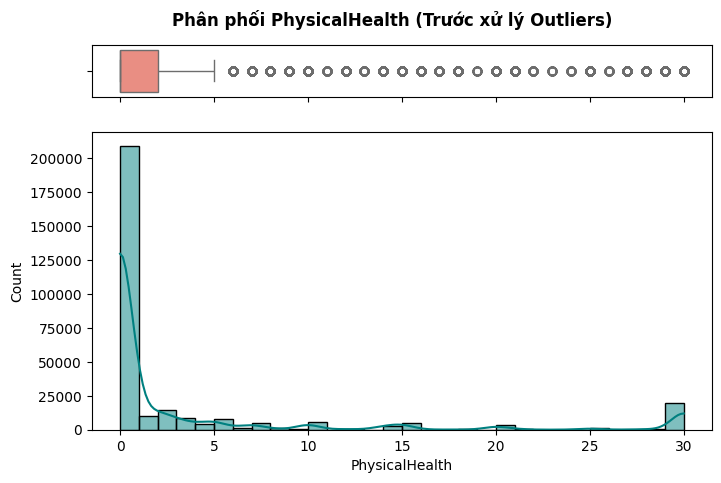

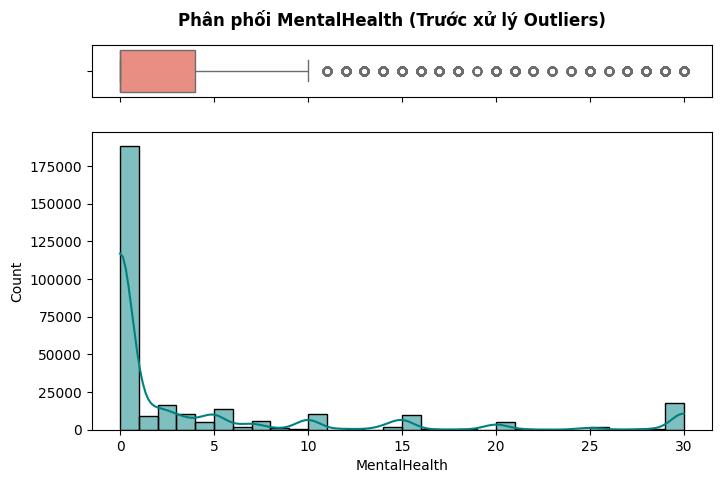

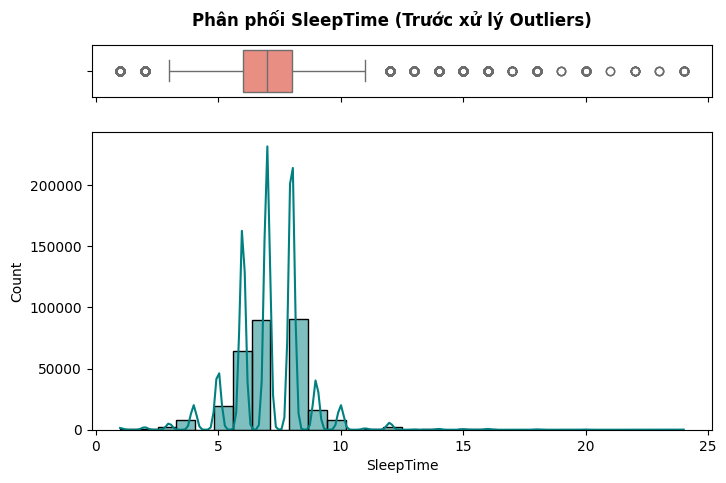

In [86]:
# Hàm vẽ biểu đồ thống nhất
def plot_unified(data, columns, title_suffix=""):
    for col in columns:
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(8, 5))
        
        sns.boxplot(x=data[col], ax=ax_box, color='salmon')
        ax_box.set(xlabel='')
        
        sns.histplot(data[col], ax=ax_hist, kde=True, color='teal', bins=30)
        
        plt.suptitle(f'Phân phối {col} {title_suffix}', y=0.95, fontweight='bold')
        plt.show()

# Vẽ cho dữ liệu gốc
print("--- TRỰC QUAN HÓA DỮ LIỆU GỐC ---")
plot_unified(df, num_cols, "(Trước xử lý Outliers)")

## Xử lý Outliers

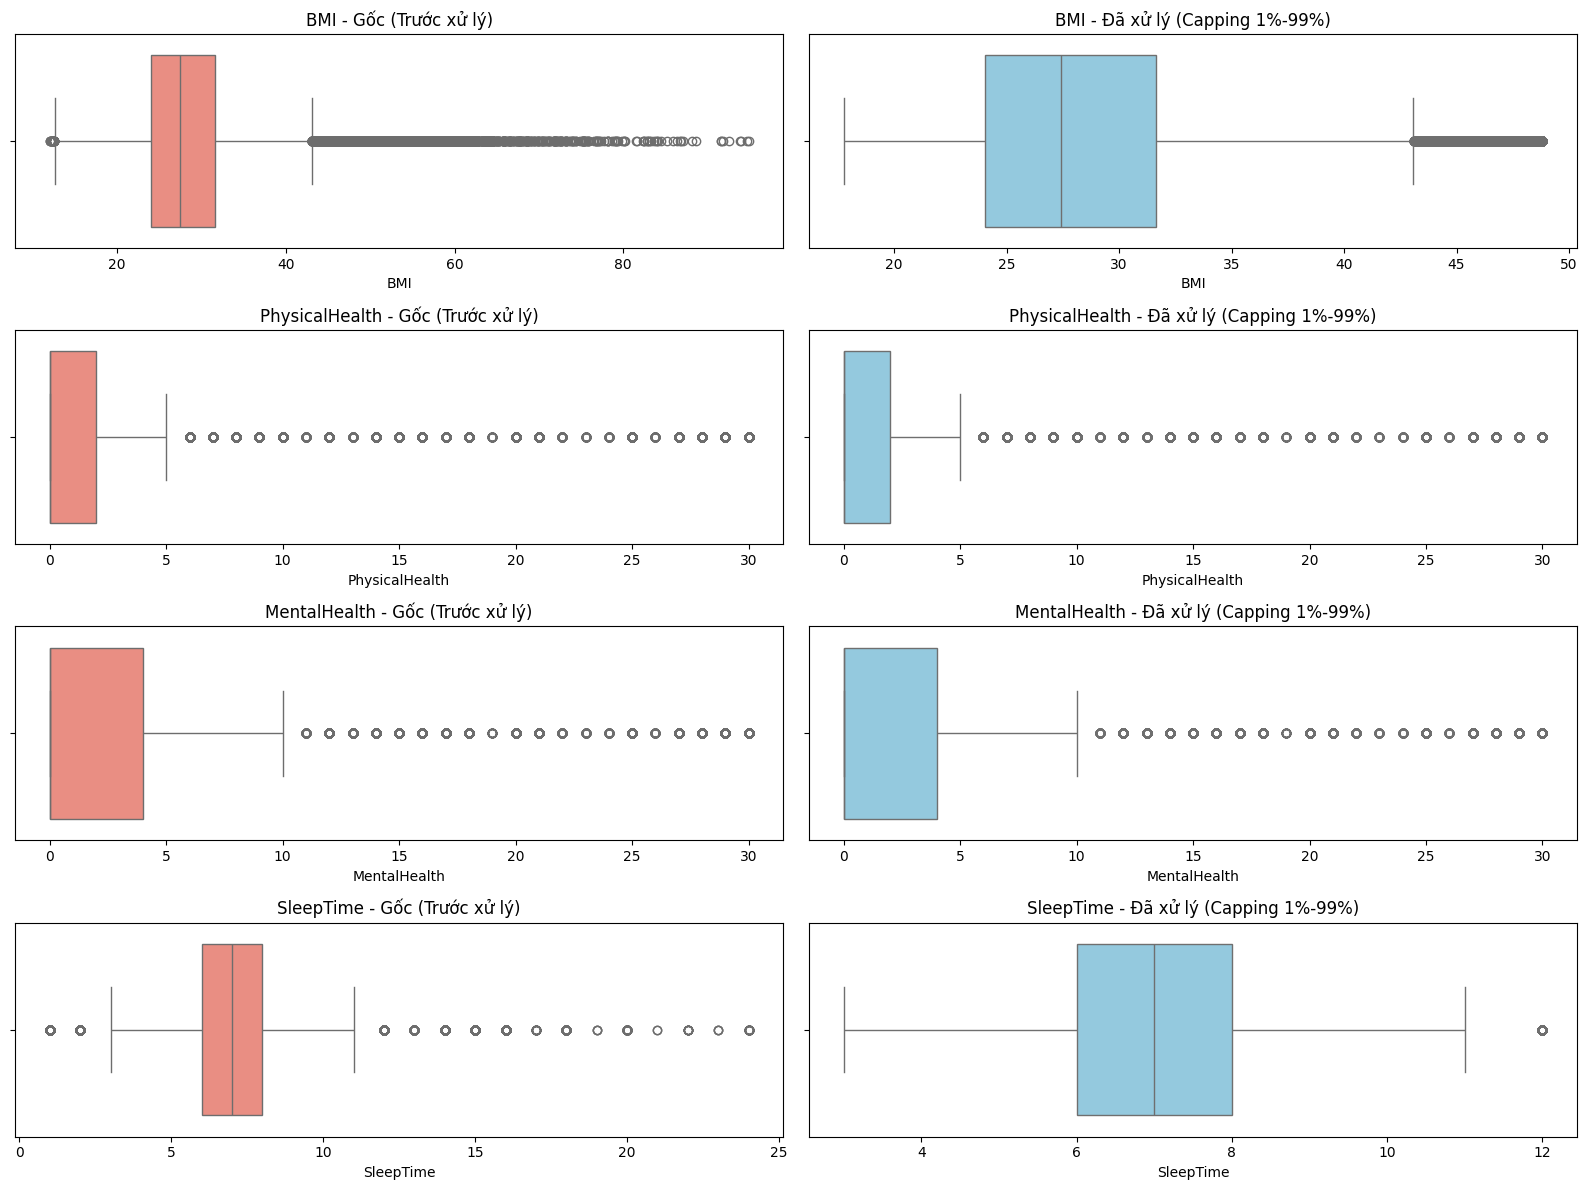

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chọn các cột số cần xử lý
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

# 2. Thực hiện Capping (Winsorization)
df_cleaned = df.copy()
for col in num_cols:
    lower_limit = df[col].quantile(0.01) # Phân vị 1%
    upper_limit = df[col].quantile(0.99) # Phân vị 99%
    df_cleaned[col] = df_cleaned[col].clip(lower_limit, upper_limit)

# 3. Vẽ đồ thị so sánh (Ví dụ cho toàn bộ các cột)
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols):
    # Trước xử lý
    plt.subplot(4, 2, 2*i + 1)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'{col} - Gốc (Trước xử lý)')
    
    # Sau xử lý
    plt.subplot(4, 2, 2*i + 2)
    sns.boxplot(x=df_cleaned[col], color='skyblue')
    plt.title(f'{col} - Đã xử lý (Capping 1%-99%)')

plt.tight_layout()
plt.show()

## Trực quan hóa các biến phân loại

C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_17828\3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_17828\3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_17828\3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\Hoang Dung\AppData\Local\Temp\i

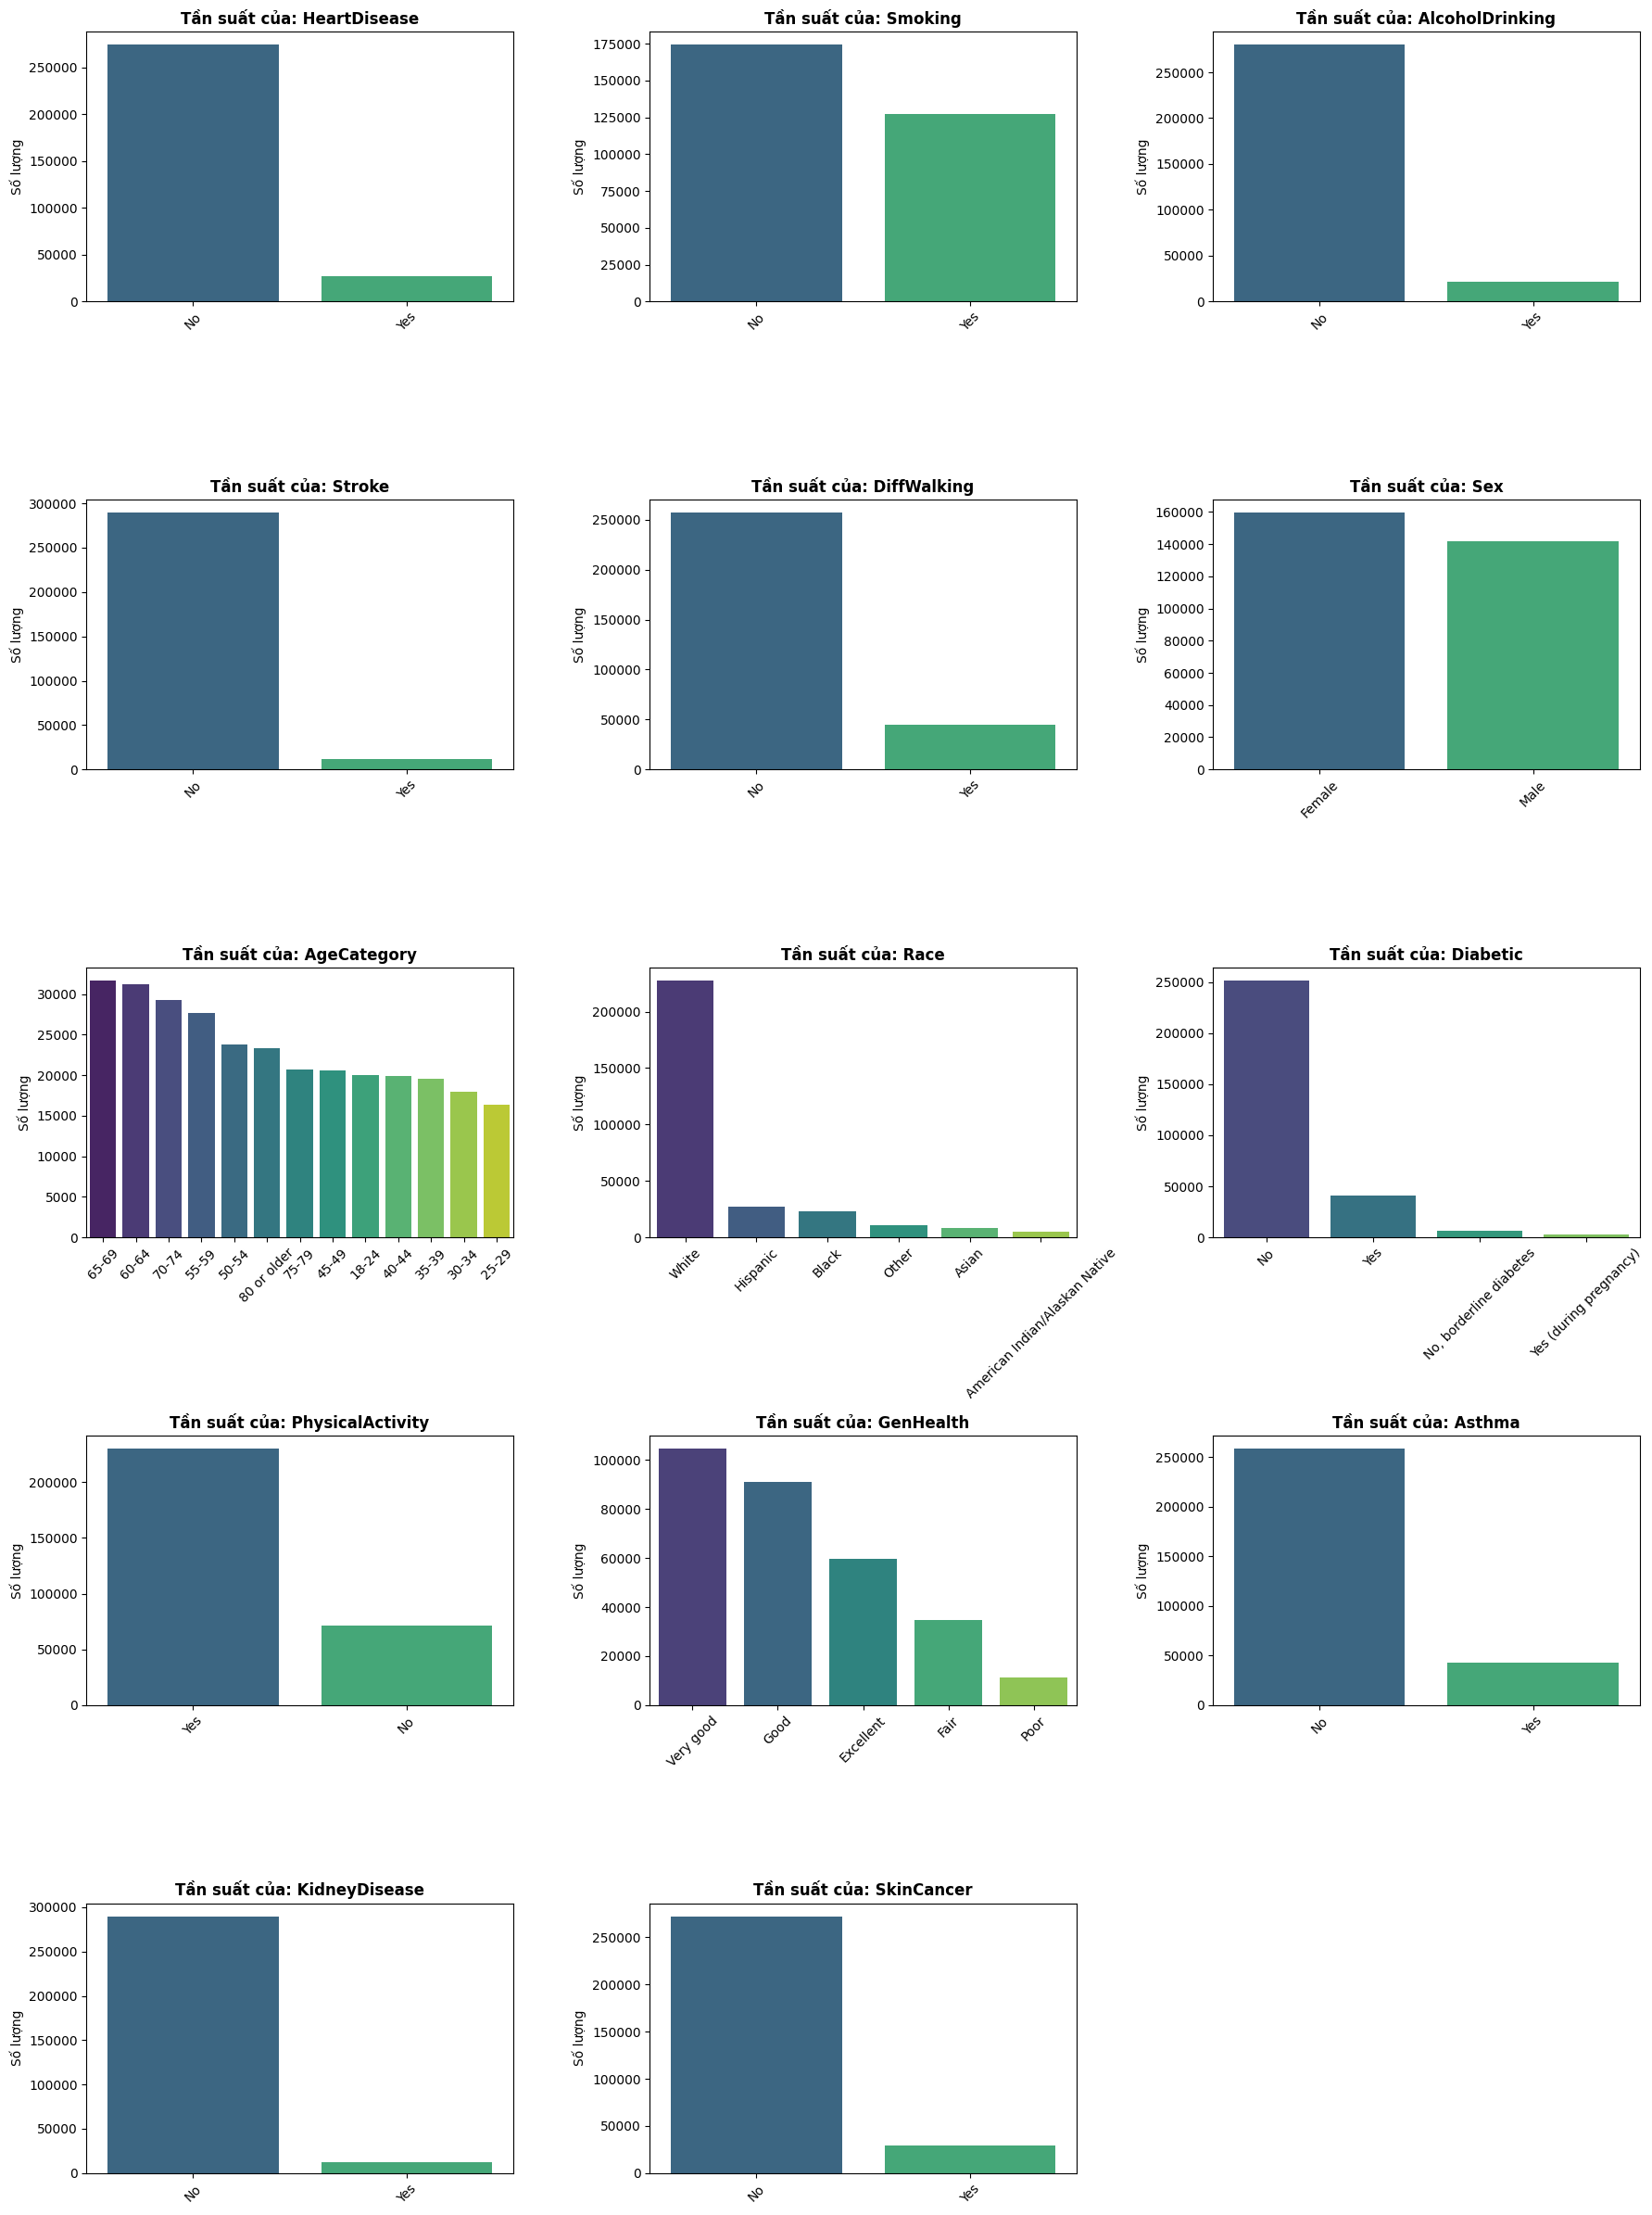

In [88]:
# Lấy danh sách các biến phân loại (loại trừ 4 biến số đã vẽ)
cat_cols = [col for col in df.columns if col not in num_cols]

# Tạo khung hình lớn chứa nhiều biểu đồ nhỏ (Grid)
plt.figure(figsize=(18, 24))

for i, col in enumerate(cat_cols):
    plt.subplot(5, 3, i+1) # Vẽ lưới 5 hàng 3 cột
    
    # Sắp xếp các cột theo số lượng từ cao xuống thấp để biểu đồ gọn gàng
    order = df[col].value_counts().index
    
    # Vẽ biểu đồ tần suất (Countplot) với màu sắc đồng bộ
    sns.countplot(data=df, x=col, order=order, palette='viridis')
    
    plt.title(f'Tần suất của: {col}', fontweight='bold')
    plt.xticks(rotation=45) # Xoay nghiêng chữ ở trục X để không bị đè lên nhau
    plt.xlabel('')
    plt.ylabel('Số lượng')

# Tự động căn chỉnh khoảng cách giữa các đồ thị
plt.tight_layout()
plt.show()

Kiểm tra phân bố nhãn HeartDisease

In [89]:
# Kiểm tra số lượng từng nhãn
label_count = df["HeartDisease"].value_counts()

# Kiểm tra tỷ lệ từng nhãn
label_ratio = df["HeartDisease"].value_counts(normalize=True)

print("Số lượng từng lớp:")
print(label_count)

print("Tỷ lệ từng lớp:")
print(label_ratio)

Số lượng từng lớp:
HeartDisease
No     274456
Yes     27261
Name: count, dtype: int64
Tỷ lệ từng lớp:
HeartDisease
No     0.909647
Yes    0.090353
Name: proportion, dtype: float64


Dữ liệu bị mất cân bằng nhãn khá rõ. Lớp No, tức không mắc bệnh tim, chiếm khoảng 91%. Lớp Yes, tức mắc bệnh tim, chỉ chiếm khoảng 9%.

Điều này có thể làm mô hình thiên về lớp chiếm đa số. Ví dụ, nếu mô hình luôn dự đoán mọi người là không mắc bệnh tim, mô hình vẫn có accuracy khoảng 91%, nhưng thực tế mô hình đó gần như vô dụng vì không phát hiện được người mắc bệnh tim.

Ví vậy khi đánh giá cần quan tâm thêm các chỉ số như :  
Precision  
Recall  
F1-score  
Confusion matrix  

Chuyển đổi dữ liệu về dạng phù hợp

Mã hóa các biến Yes/No

Các cột dạng Yes/No gồm :  
HeartDisease  
Smoking  
AlcoholDrinking  
Stroke  
DiffWalking  
PhysicalActivity  
Asthma  
KidneyDisease  
SkinCancer  

In [90]:
binary_cols = [
    "HeartDisease",
    "Smoking",
    "AlcoholDrinking",
    "Stroke",
    "DiffWalking",
    "PhysicalActivity",
    "Asthma",
    "KidneyDisease",
    "SkinCancer"
]

for col in binary_cols:
    df[col] = df[col].map({
        "No": 0,
        "Yes": 1
    })

In [91]:
# Xóa khoảng trắng thừa và chuẩn hóa chuỗi trước khi mã hóa
df['Sex'] = df['Sex'].str.strip().map({
    "Female": 0,
    "Male": 1
})

# Kiểm tra lại xem còn giá trị NaN không
print("Số giá trị NaN trong cột Sex:", df['Sex'].isnull().sum())

Số giá trị NaN trong cột Sex: 0


Mã hóa biến AgeCategory

In [92]:
age_order = [
    "18-24", "25-29", "30-34", "35-39", "40-44",
    "45-49", "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79", "80 or older"
]

age_map = {age: idx for idx, age in enumerate(age_order)}

df["AgeCategory"] = df["AgeCategory"].map(age_map)

Mã hóa biến GenHealth

In [93]:
gen_health_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very good": 4,
    "Excellent": 5
}

df["GenHealth"] = df["GenHealth"].map(gen_health_map)

One-hot encoding cho Race và Diabetic

In [94]:
df = pd.get_dummies(
    df,
    columns=["Race", "Diabetic"],
    drop_first=False,
    dtype=int
)

Đưa HeartDisease về cột đầu tiên

In [95]:
target = df.pop("HeartDisease")
df.insert(0, "HeartDisease", target)

print("Kích thước dữ liệu sau mã hóa:", df.shape)
display(df.head(15))

Kích thước dữ liệu sau mã hóa: (301717, 26)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0,16.60,1,0,0,3.0,30.0,0,0,7,...,0,0,0,0,0,1,0,0,1,0
1,0,20.34,0,0,1,0.0,0.0,0,0,12,...,0,0,0,0,0,1,1,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,...,0,0,0,0,0,1,0,0,1,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,...,0,0,0,0,0,1,1,0,0,0
4,0,23.71,0,0,0,28.0,0.0,1,0,4,...,0,0,0,0,0,1,1,0,0,0
5,1,28.87,1,0,0,6.0,0.0,1,0,11,...,0,0,1,0,0,0,1,0,0,0
6,0,21.63,0,0,0,15.0,0.0,0,0,10,...,0,0,0,0,0,1,1,0,0,0
7,0,31.64,1,0,0,5.0,0.0,1,0,12,...,0,0,0,0,0,1,0,0,1,0
8,0,26.45,0,0,0,0.0,0.0,0,0,12,...,0,0,0,0,0,1,0,1,0,0
9,0,40.69,0,0,0,0.0,0.0,1,1,9,...,0,0,0,0,0,1,1,0,0,0


## Biểu đồ tương quan(Heatmap)

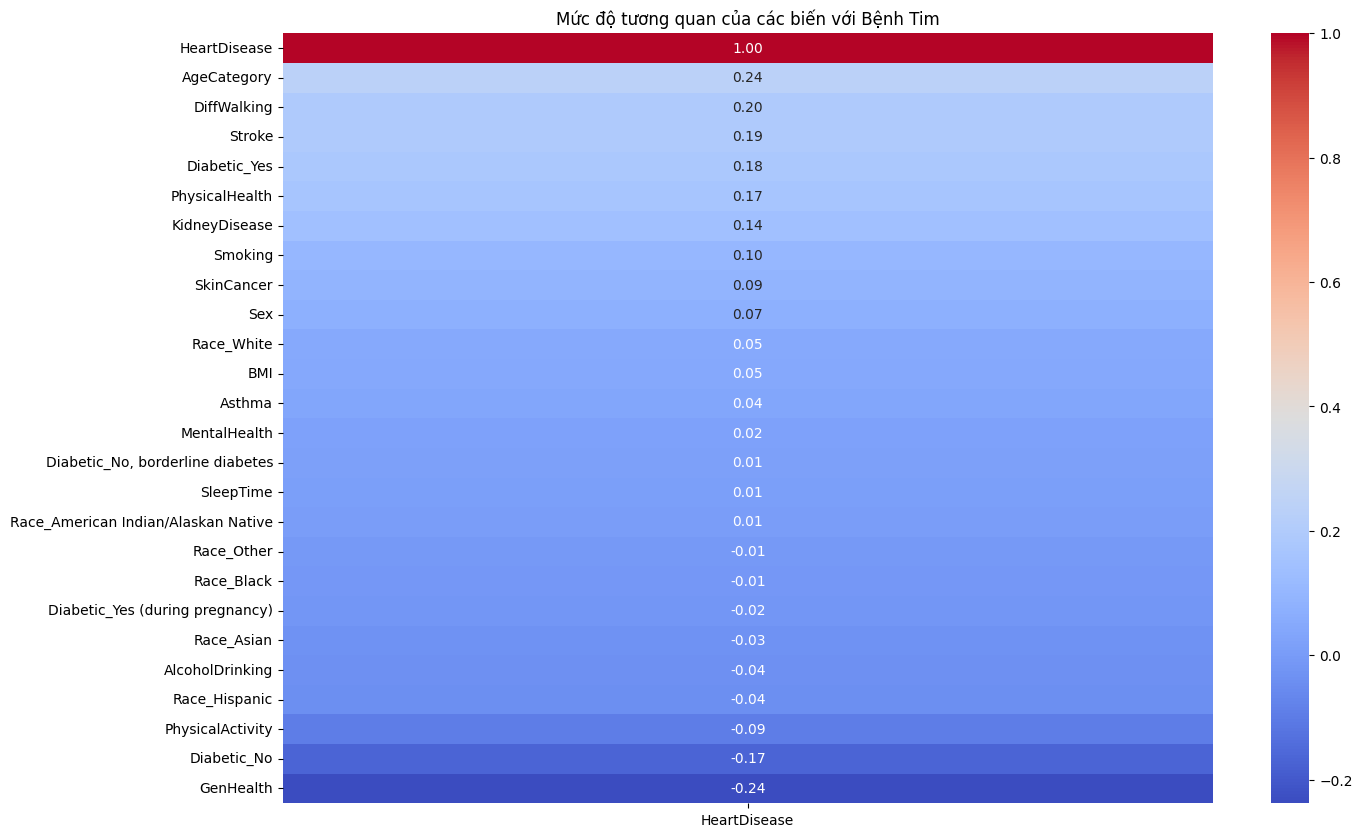

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán ma trận tương quan
# Nếu không có `df_cleaned`, dùng `df` sau tiền xử lý
corr_matrix = df.corr()

# Vẽ Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix[['HeartDisease']].sort_values(by='HeartDisease', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mức độ tương quan của các biến với Bệnh Tim')
plt.show()

## Biểu đồ tương quan giữa tất cả các biến

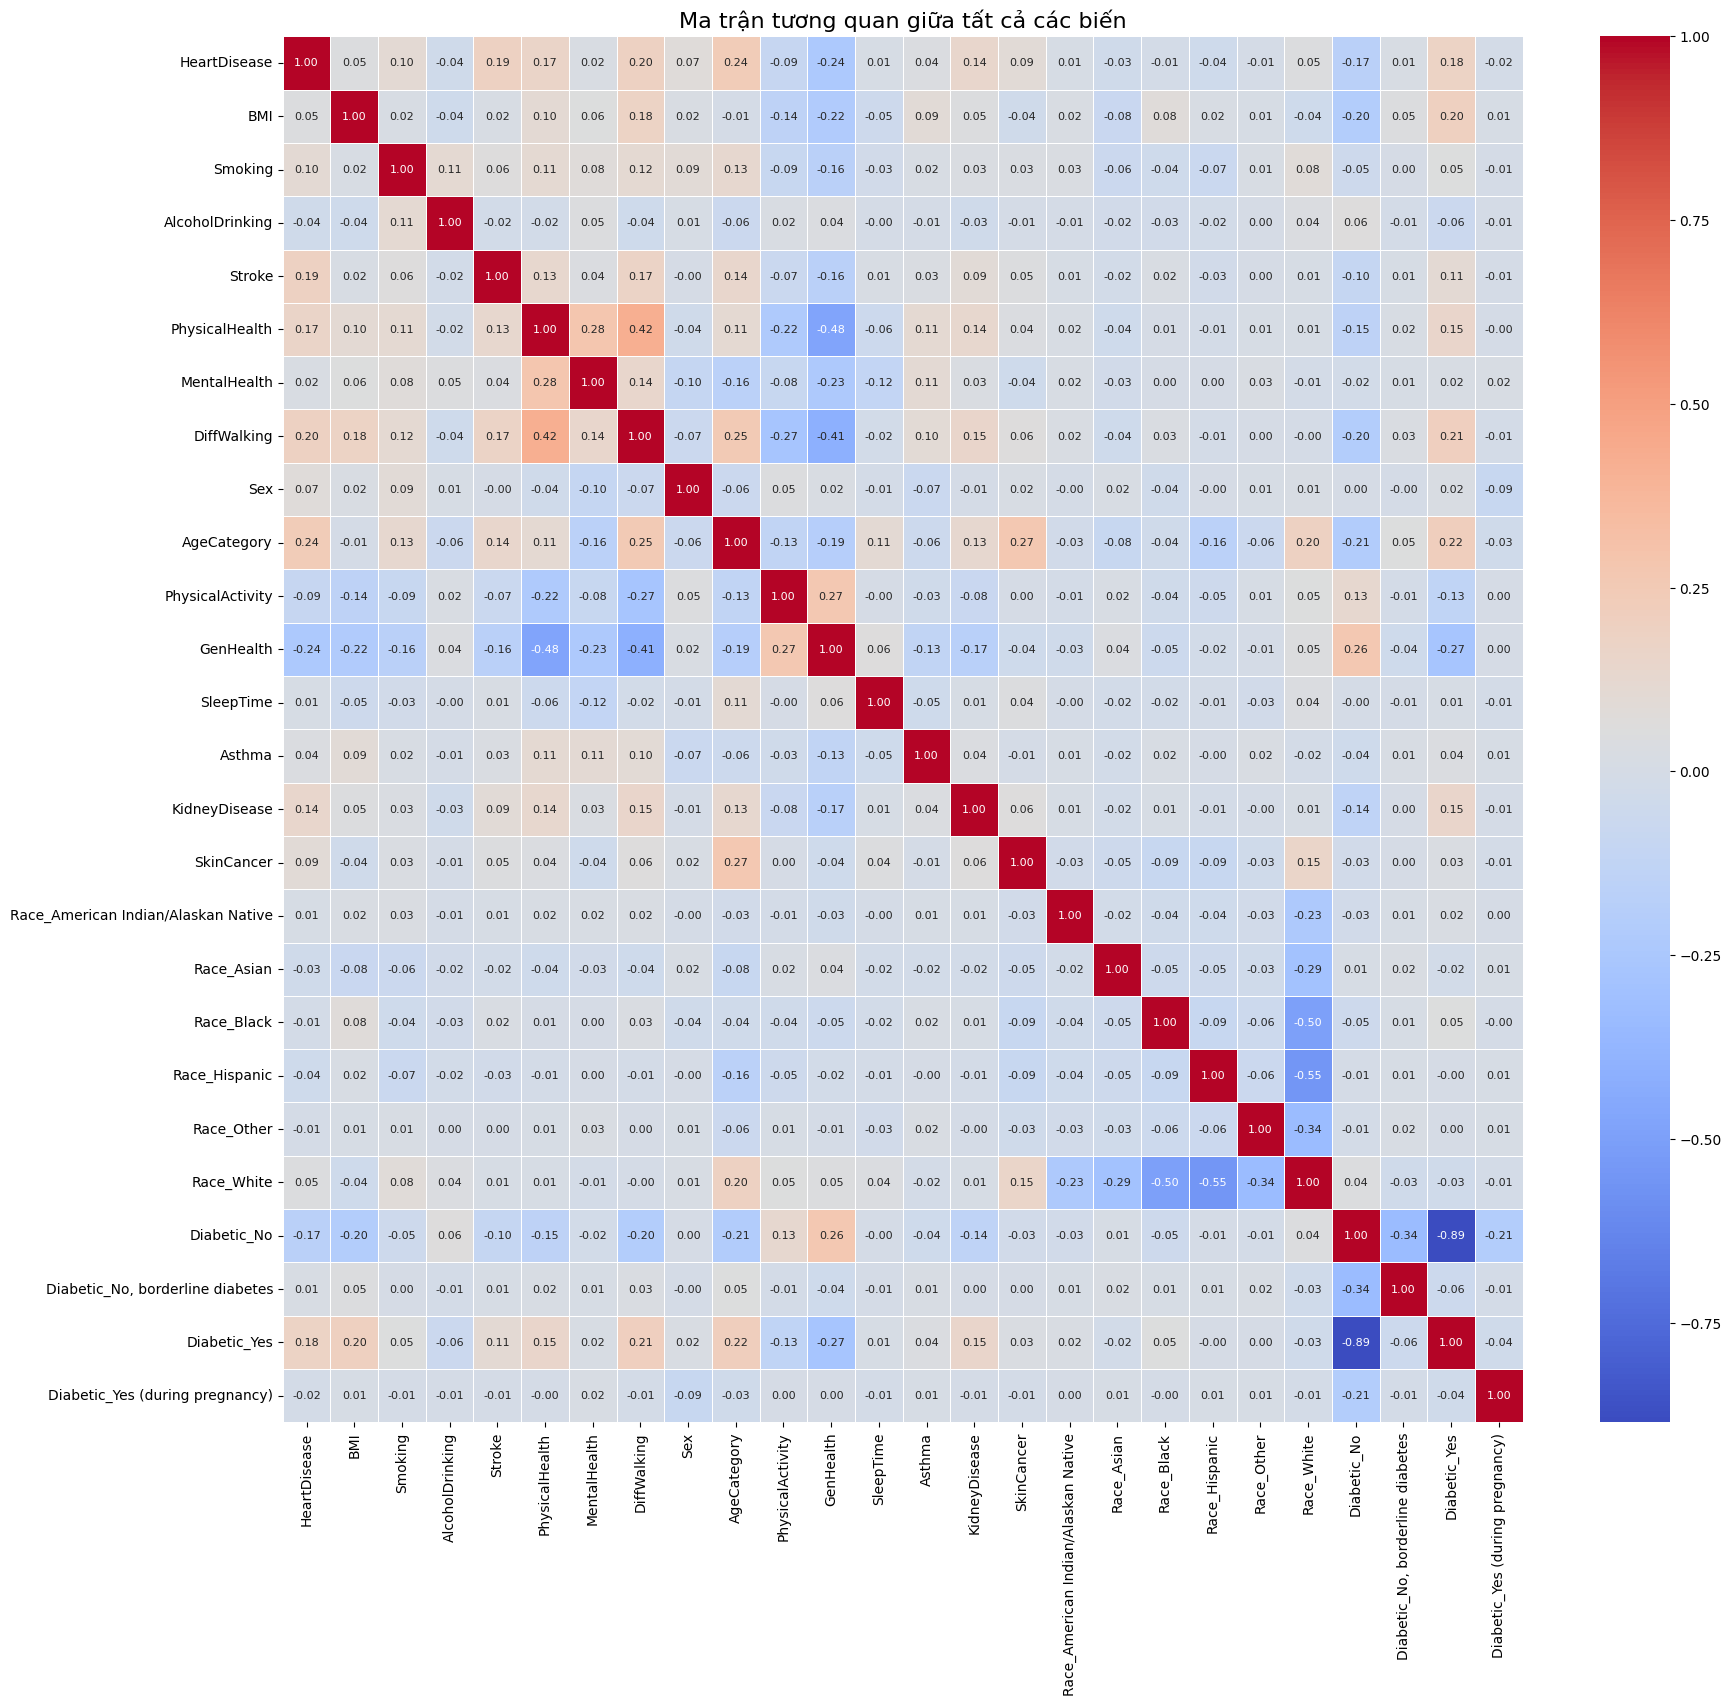

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán ma trận tương quan đầy đủ
full_corr_matrix = df.corr()

# Vẽ Heatmap cho toàn bộ ma trận tương quan
plt.figure(figsize=(20, 18)) # Kích thước lớn hơn để hiển thị nhiều biến
sns.heatmap(full_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
plt.title('Ma trận tương quan giữa tất cả các biến', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Chia dữ liệu train/test

In [98]:
from sklearn.model_selection import train_test_split

# 1. Tách biến độc lập (X) và biến mục tiêu (y)
# Dùng df sau khi đã xử lý và mã hóa để tránh còn giá trị chuỗi
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print(f"Tổng số bản ghi ban đầu: {len(df)}\n")
print("-" * 50)

# ==========================================
# TRƯỜNG HỢP 1: TỈ LỆ 4:1 (80% Train - 20% Test)
# Đây là tỉ lệ "Vàng" phổ biến nhất.
# ==========================================
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("1. KẾT QUẢ CHIA TỈ LỆ 4:1 (80/20)")
print(f"   - Tập Train (80%): {X_train_80.shape[0]} dòng")
print(f"   - Tập Test  (20%): {X_test_20.shape[0]} dòng")
print("-" * 50)


# ==========================================
# TRƯỜNG HỢP 2: TỈ LỆ 7:3 (70% Train - 30% Test)
# Dùng khi bộ dữ liệu cực lớn, cần tập Test lớn hơn để đánh giá chắc chắn.
# ==========================================
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("2. KẾT QUẢ CHIA TỈ LỆ 7:3 (70/30)")
print(f"   - Tập Train (70%): {X_train_70.shape[0]} dòng")
print(f"   - Tập Test  (30%): {X_test_30.shape[0]} dòng")
print("-" * 50)


# ==========================================
# TRƯỜNG HỢP 3: TỈ LỆ 6:4 (60% Train - 40% Test)
# Dùng để kiểm tra xem mô hình có bị Overfitting nặng không khi thiếu dữ liệu học.
# ==========================================
X_train_60, X_test_40, y_train_60, y_test_40 = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
print("3. KẾT QUẢ CHIA TỈ LỆ 6:4 (60/40)")
print(f"   - Tập Train (60%): {X_train_60.shape[0]} dòng")
print(f"   - Tập Test  (40%): {X_test_40.shape[0]} dòng")
print("-" * 50)

Tổng số bản ghi ban đầu: 301717

--------------------------------------------------
1. KẾT QUẢ CHIA TỈ LỆ 4:1 (80/20)
   - Tập Train (80%): 241373 dòng
   - Tập Test  (20%): 60344 dòng
--------------------------------------------------
2. KẾT QUẢ CHIA TỈ LỆ 7:3 (70/30)
   - Tập Train (70%): 211201 dòng
   - Tập Test  (30%): 90516 dòng
--------------------------------------------------
3. KẾT QUẢ CHIA TỈ LỆ 6:4 (60/40)
   - Tập Train (60%): 181030 dòng
   - Tập Test  (40%): 120687 dòng
--------------------------------------------------


tham số stratify=y đảm bảo người mắc bệnh có tỉ lệ đồng đều ở cả 2 tập


## Chuẩn hóa các dữ liệu dạng số 

In [99]:
from sklearn.preprocessing import StandardScaler

def scale_data(X_train, X_test):
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)  # fit + transform train
    X_test_scaled = scaler.transform(X_test)        # chỉ transform test
    
    return X_train_scaled, X_test_scaled, scaler

# 80/20
X_train_80_s, X_test_20_s, scaler_80 = scale_data(X_train_80, X_test_20)

# 70/30
X_train_70_s, X_test_30_s, scaler_70 = scale_data(X_train_70, X_test_30)

# 60/40
X_train_60_s, X_test_40_s, scaler_60 = scale_data(X_train_60, X_test_40)

In [100]:
import pandas as pd

def show_scaled_data(X_train, X_test, X_train_scaled, X_test_scaled, name):
    # Lấy tên cột
    cols = X_train.columns
    
    # Convert về DataFrame
    train_df = pd.DataFrame(X_train_scaled, columns=cols)
    test_df  = pd.DataFrame(X_test_scaled, columns=cols)
    
    print(f"\n===== {name} =====")
    
    print("\nTrain sau chuẩn hóa:")
    print(display(train_df.head()))
    
    print("\nTest sau chuẩn hóa:")
    print(display(test_df.head()))
    
    print("\nThống kê Train:")
    print(train_df.describe().loc[['mean','std']])

In [101]:
# 80/20
show_scaled_data(
    X_train_80, X_test_20,
    X_train_80_s, X_test_20_s,
    "80/20"
)

# 70/30
show_scaled_data(
    X_train_70, X_test_30,
    X_train_70_s, X_test_30_s,
    "70/30"
)

# 60/40
show_scaled_data(
    X_train_60, X_test_40,
    X_train_60_s, X_test_40_s,
    "60/40"
)


===== 80/20 =====

Train sau chuẩn hóa:


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0.474667,-0.853203,-0.277247,-0.204554,-0.439058,-0.137842,-0.415844,-0.944501,-0.142151,0.555609,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,0.44439,-0.151561,-0.393166,-0.093006
1,-1.067100,-0.853203,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,-0.944501,0.695189,0.555609,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,0.44439,-0.151561,-0.393166,-0.093006
2,0.539616,1.172053,-0.277247,-0.204554,1.277402,-0.506526,-0.415844,1.058760,-0.142151,-1.799826,...,-0.132200,-0.165116,3.501334,-0.314823,-0.192815,-1.754719,0.44439,-0.151561,-0.393166,-0.093006
3,-0.600086,-0.853203,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,-0.944501,-1.816830,-1.799826,...,-0.132200,-0.165116,-0.285605,3.176390,-0.192815,-1.754719,0.44439,-0.151561,-0.393166,-0.093006
4,1.359212,1.172053,-0.277247,-0.204554,0.051359,-0.506526,-0.415844,1.058760,0.416075,0.555609,...,7.564277,-0.165116,-0.285605,-0.314823,-0.192815,-1.754719,0.44439,-0.151561,-0.393166,-0.093006


None

Test sau chuẩn hóa:


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,-0.399053,1.172053,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,-0.944501,1.253415,0.555609,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,0.444390,-0.151561,-0.393166,-0.093006
1,-0.204205,-0.853203,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,1.058760,-1.258604,-1.799826,...,-0.132200,-0.165116,-0.285605,3.176390,-0.192815,-1.754719,0.444390,-0.151561,-0.393166,-0.093006
2,-0.562972,1.172053,-0.277247,-0.204554,-0.439058,-0.260737,-0.415844,-0.944501,-1.816830,0.555609,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,0.444390,-0.151561,-0.393166,-0.093006
3,-0.204205,1.172053,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,1.058760,-1.816830,0.555609,...,7.564277,-0.165116,-0.285605,-0.314823,-0.192815,-1.754719,0.444390,-0.151561,-0.393166,-0.093006
4,2.382933,1.172053,-0.277247,-0.204554,1.400006,-0.506526,-0.415844,1.058760,0.974302,-1.799826,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,-2.250274,-0.151561,2.543452,-0.093006


None

Thống kê Train:
               BMI       Smoking  AlcoholDrinking        Stroke  \
mean  5.216332e-16 -4.715894e-17     3.938743e-17 -6.311409e-17   
std   1.000002e+00  1.000002e+00     1.000002e+00  1.000002e+00   

      PhysicalHealth  MentalHealth   DiffWalking           Sex   AgeCategory  \
mean    5.298757e-17 -2.531628e-17 -8.831262e-17 -2.143053e-17 -8.230736e-17   
std     1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

      PhysicalActivity  ...  Race_American Indian/Alaskan Native  \
mean      5.969933e-17  ...                         2.625829e-17   
std       1.000002e+00  ...                         1.000002e+00   

        Race_Asian    Race_Black  Race_Hispanic    Race_Other    Race_White  \
mean -1.554302e-17  1.507202e-17  -3.026179e-17  4.215456e-17  7.371160e-17   
std   1.000002e+00  1.000002e+00   1.000002e+00  1.000002e+00  1.000002e+00   

       Diabetic_No  Diabetic_No, borderline diabetes  Diabetic_Yes  \
mean -1.175883e-16    

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,-0.971910,-0.852283,-0.276292,-0.203443,-0.439403,-0.506355,-0.415823,-0.943296,1.531831,-1.797369,...,-0.131666,-0.164961,-0.285514,-0.314766,-0.193178,0.569694,0.443625,-0.151765,-0.392464,-0.09235
1,-0.286579,1.173319,-0.276292,-0.203443,0.172947,-0.506355,-0.415823,1.060113,0.416319,0.556369,...,-0.131666,-0.164961,-0.285514,-0.314766,-0.193178,0.569694,0.443625,-0.151765,-0.392464,-0.09235
2,-0.048874,-0.852283,-0.276292,-0.203443,-0.439403,-0.506355,-0.415823,1.060113,-0.699194,0.556369,...,-0.131666,-0.164961,3.502460,-0.314766,-0.193178,-1.755329,-2.254158,-0.151765,2.548003,-0.09235
3,0.861813,1.173319,-0.276292,-0.203443,-0.316933,-0.506355,-0.415823,-0.943296,0.137441,0.556369,...,-0.131666,-0.164961,3.502460,-0.314766,-0.193178,-1.755329,0.443625,-0.151765,-0.392464,-0.09235
4,0.483646,1.173319,-0.276292,-0.203443,-0.439403,-0.506355,-0.415823,1.060113,0.416319,0.556369,...,-0.131666,-0.164961,-0.285514,-0.314766,-0.193178,0.569694,-2.254158,6.589128,-0.392464,-0.09235


None

Test sau chuẩn hóa:


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0.776919,-0.852283,-0.276292,-0.203443,-0.439403,-0.137260,-0.415823,-0.943296,-0.699194,0.556369,...,-0.131666,-0.164961,-0.285514,-0.314766,5.176574,-1.755329,0.443625,-0.151765,-0.392464,-0.092350
1,-0.536632,-0.852283,-0.276292,-0.203443,-0.439403,-0.137260,-0.415823,-0.943296,-0.699194,0.556369,...,-0.131666,-0.164961,3.502460,-0.314766,-0.193178,-1.755329,0.443625,-0.151765,-0.392464,-0.092350
2,-0.670920,-0.852283,-0.276292,-0.203443,-0.439403,-0.506355,-0.415823,-0.943296,0.695197,0.556369,...,-0.131666,-0.164961,-0.285514,-0.314766,5.176574,-1.755329,-2.254158,-0.151765,-0.392464,10.828372
3,0.424992,1.173319,-0.276292,-0.203443,-0.439403,-0.506355,-0.415823,1.060113,0.974075,0.556369,...,-0.131666,-0.164961,-0.285514,-0.314766,-0.193178,0.569694,0.443625,-0.151765,-0.392464,-0.092350
4,2.604468,1.173319,-0.276292,-0.203443,1.275178,-0.506355,2.404869,-0.943296,-0.141438,0.556369,...,-0.131666,-0.164961,-0.285514,-0.314766,-0.193178,0.569694,0.443625,-0.151765,-0.392464,-0.092350


None

Thống kê Train:
               BMI       Smoking  AlcoholDrinking        Stroke  \
mean  3.792235e-16  5.086816e-17    -7.307251e-17  2.314636e-17   
std   1.000002e+00  1.000002e+00     1.000002e+00  1.000002e+00   

      PhysicalHealth  MentalHealth   DiffWalking           Sex   AgeCategory  \
mean   -2.624151e-17 -1.830177e-17 -1.406276e-17  1.049660e-17 -2.072407e-17   
std     1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

      PhysicalActivity  ...  Race_American Indian/Alaskan Native  \
mean      6.553649e-17  ...                         3.633440e-17   
std       1.000002e+00  ...                         1.000002e+00   

        Race_Asian    Race_Black  Race_Hispanic    Race_Other    Race_White  \
mean  3.270096e-17  3.054781e-17  -3.297010e-17  5.382874e-17 -7.966654e-17   
std   1.000002e+00  1.000002e+00   1.000002e+00  1.000002e+00  1.000002e+00   

       Diabetic_No  Diabetic_No, borderline diabetes  Diabetic_Yes  \
mean -5.355960e-17    

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,-1.211216,1.173377,3.616968,-0.202057,-0.316501,1.218683,-0.414706,-0.943472,-1.537935,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
1,-1.257588,-0.852241,-0.276475,-0.202057,0.541871,-0.382810,-0.414706,-0.943472,0.416508,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
2,0.380895,1.173377,-0.276475,4.949100,2.626489,3.189750,2.411349,-0.943472,-0.979523,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,-2.255639,6.636531,-0.392567,-0.092749
3,-1.211216,-0.852241,-0.276475,-0.202057,-0.439126,-0.506001,-0.414706,-0.943472,-1.258729,0.555847,...,-0.131539,-0.164895,-0.285266,3.185354,-0.19246,-1.759434,0.443333,-0.150681,-0.392567,-0.092749
4,-0.353331,-0.852241,-0.276475,-0.202057,-0.439126,3.189750,-0.414706,-0.943472,1.254127,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749


None

Test sau chuẩn hóa:


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0.688497,-0.852241,-0.276475,-0.202057,-0.439126,-0.506001,-0.414706,1.059915,0.137302,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
1,-0.902068,-0.852241,-0.276475,-0.202057,-0.439126,1.957833,-0.414706,-0.943472,-0.979523,0.555847,...,-0.131539,-0.164895,-0.285266,3.185354,-0.19246,-1.759434,0.443333,-0.150681,-0.392567,-0.092749
2,-1.053551,1.173377,-0.276475,-0.202057,-0.439126,-0.506001,-0.414706,1.059915,-1.537935,-1.799056,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
3,-0.885065,1.173377,-0.276475,-0.202057,-0.439126,-0.506001,-0.414706,-0.943472,1.254127,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
4,-0.719671,-0.852241,-0.276475,-0.202057,3.239611,-0.506001,2.411349,-0.943472,1.254127,0.555847,...,-0.131539,-0.164895,-0.285266,3.185354,-0.19246,-1.759434,0.443333,-0.150681,-0.392567,-0.092749


None

Thống kê Train:
               BMI       Smoking  AlcoholDrinking        Stroke  \
mean -6.625400e-17 -9.058900e-17    -3.328400e-17 -2.574800e-17   
std   1.000003e+00  1.000003e+00     1.000003e+00  1.000003e+00   

      PhysicalHealth  MentalHealth   DiffWalking           Sex   AgeCategory  \
mean    7.693000e-18 -1.193200e-17 -1.829050e-17  2.614050e-17  2.205850e-17   
std     1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00   

      PhysicalActivity  ...  Race_American Indian/Alaskan Native  \
mean      3.430450e-17  ...                         4.804200e-17   
std       1.000003e+00  ...                         1.000003e+00   

        Race_Asian    Race_Black  Race_Hispanic    Race_Other    Race_White  \
mean -1.146100e-17 -7.536000e-17   4.427400e-17  3.956400e-17 -5.338000e-18   
std   1.000003e+00  1.000003e+00   1.000003e+00  1.000003e+00  1.000003e+00   

       Diabetic_No  Diabetic_No, borderline diabetes  Diabetic_Yes  \
mean -2.213700e-17    

In [102]:
import numpy as np

def check_scaling(X_train_s, X_test_s, name):
    print(f"\n=== {name} ===")
    print("Train mean (≈0):", np.mean(X_train_s, axis=0)[:5])
    print("Train std  (≈1):", np.std(X_train_s, axis=0)[:5])
    
    print("Test mean  :", np.mean(X_test_s, axis=0)[:5])
    print("Test std   :", np.std(X_test_s, axis=0)[:5])

# Kiểm tra 3 bộ
check_scaling(X_train_80_s, X_test_20_s, "80/20")
check_scaling(X_train_70_s, X_test_30_s, "70/30")
check_scaling(X_train_60_s, X_test_40_s, "60/40")


=== 80/20 ===
Train mean (≈0): [ 5.21633210e-16 -4.71589392e-17  3.93874286e-17 -6.31140859e-17
  5.29875721e-17]
Train std  (≈1): [1. 1. 1. 1. 1.]
Test mean  : [ 0.00112477  0.00997405  0.00287696 -0.00451812 -0.00539367]
Test std   : [1.00117422 1.00153919 1.0047741  0.98935136 0.99033838]

=== 70/30 ===
Train mean (≈0): [ 3.79223475e-16  5.08681595e-17 -7.30725149e-17  2.31463583e-17
 -2.62415109e-17]
Train std  (≈1): [1. 1. 1. 1. 1.]
Test mean  : [ 0.00274367  0.01020203  0.0078475   0.00410114 -0.00634592]
Test std   : [0.99458543 1.00158431 1.01300206 1.00960759 0.98990052]

=== 60/40 ===
Train mean (≈0): [-6.62539987e-17 -9.05889982e-17 -3.32839993e-17 -2.57479995e-17
  7.69299985e-18]
Train std  (≈1): [1. 1. 1. 1. 1.]
Test mean  : [ 0.00236958  0.00777426  0.0050319   0.00977361 -0.00268563]
Test std   : [0.99950569 1.00121734 1.00835694 1.02288818 0.99559918]


## Phương pháp giảm chiều dữ liệu LDA

In [103]:
import numpy as np

class LDA_Manual:
    def fit(self, X, y):
        # Tách lớp
        X0 = X[y == 0]
        X1 = X[y == 1]
        
        # Mean
        self.mu0 = np.mean(X0, axis=0)
        self.mu1 = np.mean(X1, axis=0)
        
        # Prior
        self.pi0 = len(X0) / len(X)
        self.pi1 = len(X1) / len(X)
        
        # Covariance chung
        S0 = np.cov(X0, rowvar=False)
        S1 = np.cov(X1, rowvar=False)
        self.Sigma = (S0 * (len(X0)-1) + S1 * (len(X1)-1)) / (len(X)-2)
        
        # Inverse
        self.Sigma_inv = np.linalg.pinv(self.Sigma)
        
        return self

    def _delta(self, X, mu, pi):
        return (
            X @ self.Sigma_inv @ mu
            - 0.5 * mu.T @ self.Sigma_inv @ mu
            + np.log(pi)
        )

    def predict(self, X):
        d0 = self._delta(X, self.mu0, self.pi0)
        d1 = self._delta(X, self.mu1, self.pi1)
        return (d1 > d0).astype(int)

    def predict_proba(self, X):
        d0 = self._delta(X, self.mu0, self.pi0)
        d1 = self._delta(X, self.mu1, self.pi1)
        
        # softmax 2 class
        exp0 = np.exp(d0)
        exp1 = np.exp(d1)
        
        p1 = exp1 / (exp0 + exp1)
        return np.vstack([1 - p1, p1]).T

In [104]:
from sklearn.metrics import classification_report, roc_auc_score

def run_manual_lda(X_train, X_test, y_train, y_test, name):
    
    model = LDA_Manual()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n===== {name} (Manual LDA) =====")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

In [105]:
# 80/20
run_manual_lda(X_train_80_s, X_test_20_s, y_train_80, y_test_20, "80/20")


===== 80/20 (Manual LDA) =====
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     54892
           1       0.44      0.22      0.29      5452

    accuracy                           0.90     60344
   macro avg       0.68      0.59      0.62     60344
weighted avg       0.88      0.90      0.89     60344

ROC-AUC: 0.8245698907650261


In [106]:
# 70/30
run_manual_lda(X_train_70_s, X_test_30_s, y_train_70, y_test_30, "70/30")



===== 70/30 (Manual LDA) =====
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     82338
           1       0.44      0.22      0.29      8178

    accuracy                           0.90     90516
   macro avg       0.68      0.59      0.62     90516
weighted avg       0.88      0.90      0.89     90516

ROC-AUC: 0.8245889951399026


In [107]:
# 60/40
run_manual_lda(X_train_60_s, X_test_40_s, y_train_60, y_test_40, "60/40")


===== 60/40 (Manual LDA) =====
              precision    recall  f1-score   support

           0       0.93      0.97      0.95    109783
           1       0.43      0.22      0.29     10904

    accuracy                           0.90    120687
   macro avg       0.68      0.59      0.62    120687
weighted avg       0.88      0.90      0.89    120687

ROC-AUC: 0.824741469246318


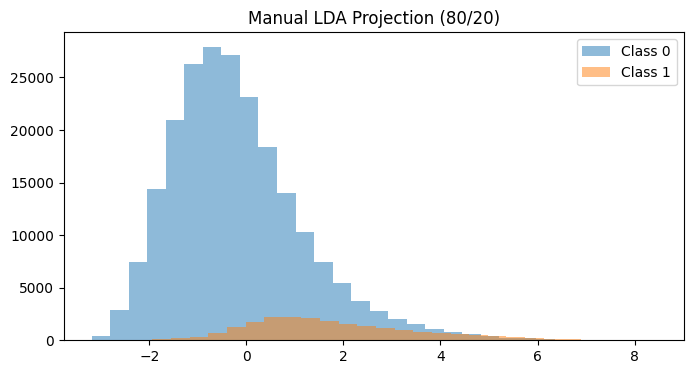

In [108]:
import matplotlib.pyplot as plt

# Train model
lda_manual = LDA_Manual()
lda_manual.fit(X_train_80_s, y_train_80)

# Vector chiếu
w = lda_manual.Sigma_inv @ (lda_manual.mu1 - lda_manual.mu0)

# Chiếu dữ liệu
X_proj = X_train_80_s @ w

# Vẽ
plt.figure(figsize=(8,4))

plt.hist(X_proj[y_train_80 == 0], bins=30, alpha=0.5, label="Class 0")
plt.hist(X_proj[y_train_80 == 1], bins=30, alpha=0.5, label="Class 1")

plt.title("Manual LDA Projection (80/20)")
plt.legend()
plt.show()

In [109]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_sklearn = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda_sklearn.fit_transform(X_train_80_s, y_train_80)

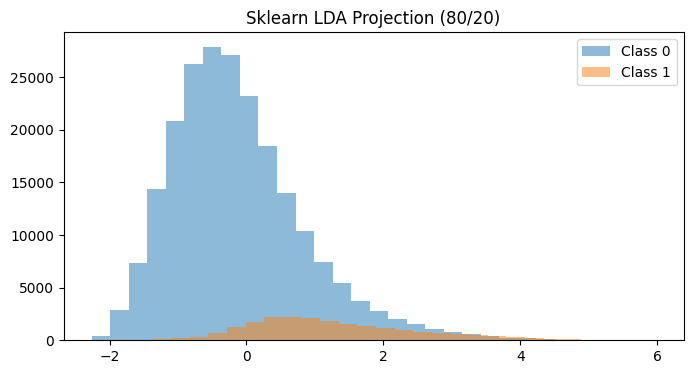

In [110]:
plt.figure(figsize=(8,4))

plt.hist(X_train_lda[y_train_80 == 0], bins=30, alpha=0.5, label="Class 0")
plt.hist(X_train_lda[y_train_80 == 1], bins=30, alpha=0.5, label="Class 1")

plt.title("Sklearn LDA Projection (80/20)")
plt.legend()
plt.show()

In [111]:
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def plot_lda_3sets(
    X_train_80_s, y_train_80,
    X_train_70_s, y_train_70,
    X_train_60_s, y_train_60
):
    plt.figure(figsize=(15, 5))
    
    datasets = [
        (X_train_80_s, y_train_80, "80/20"),
        (X_train_70_s, y_train_70, "70/30"),
        (X_train_60_s, y_train_60, "60/40"),
    ]
    
    for i, (X, y, name) in enumerate(datasets):
        lda = LinearDiscriminantAnalysis(n_components=1)
        X_lda = lda.fit_transform(X, y)
        
        plt.subplot(1, 3, i+1)
        
        plt.hist(X_lda[y == 0], bins=30, alpha=0.5, label="Class 0")
        plt.hist(X_lda[y == 1], bins=30, alpha=0.5, label="Class 1")
        
        plt.title(f"LDA Projection ({name})")
        plt.xlabel("LDA Component")
        plt.ylabel("Frequency")
        plt.legend()
    
    plt.tight_layout()
    plt.show()

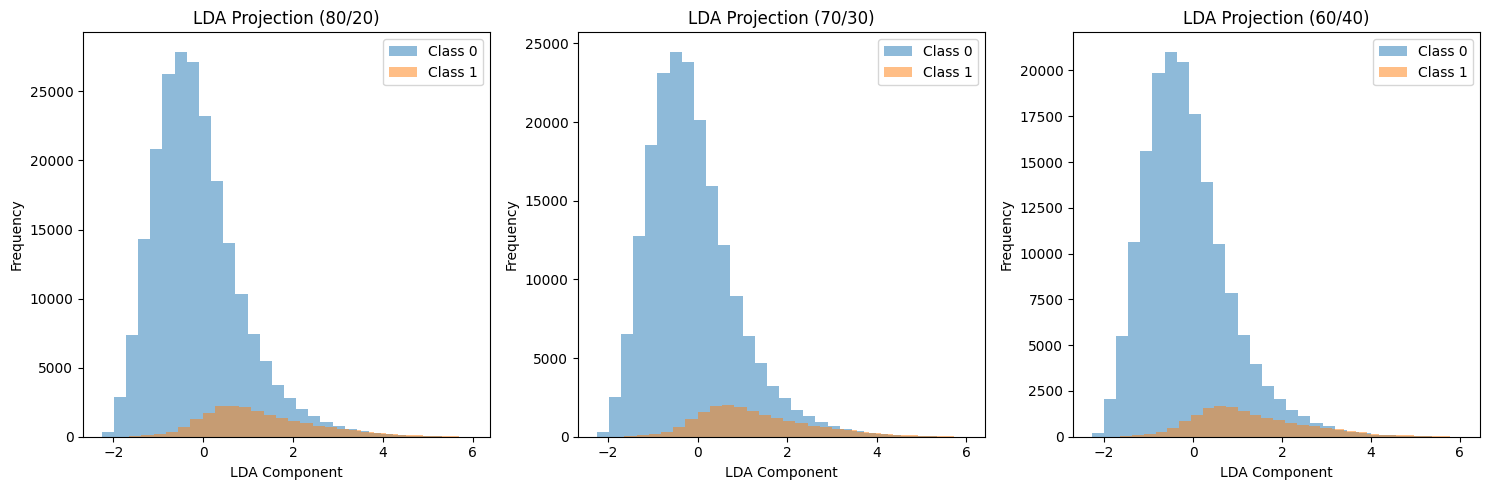

In [112]:
plot_lda_3sets(
    X_train_80_s, y_train_80,
    X_train_70_s, y_train_70,
    X_train_60_s, y_train_60
)

## Mô hình GaussianNB

In [113]:
from sklearn.naive_bayes import GaussianNB

nb_80 = GaussianNB()
nb_70 = GaussianNB()
nb_60 = GaussianNB()

In [114]:
# Train
nb_80.fit(X_train_80_s, y_train_80)
nb_70.fit(X_train_70_s, y_train_70)
nb_60.fit(X_train_60_s, y_train_60)

,priors,None
,var_smoothing,1e-09


In [115]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate_nb(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [116]:
evaluate_nb(nb_80, X_test_20_s, y_test_20, "NB 80/20 (Original)")
evaluate_nb(nb_70, X_test_30_s, y_test_30, "NB 70/30 (Original)")
evaluate_nb(nb_60, X_test_40_s, y_test_40, "NB 60/40 (Original)")


===== NB 80/20 (Original) =====
              precision    recall  f1-score   support

           0       0.95      0.83      0.88     54892
           1       0.24      0.55      0.34      5452

    accuracy                           0.80     60344
   macro avg       0.60      0.69      0.61     60344
weighted avg       0.88      0.80      0.83     60344

ROC-AUC: 0.7865343059557648
Confusion Matrix:
[[45481  9411]
 [ 2456  2996]]

===== NB 70/30 (Original) =====
              precision    recall  f1-score   support

           0       0.95      0.83      0.89     82338
           1       0.24      0.55      0.34      8178

    accuracy                           0.80     90516
   macro avg       0.60      0.69      0.61     90516
weighted avg       0.89      0.80      0.84     90516

ROC-AUC: 0.7882002921693478
Confusion Matrix:
[[68268 14070]
 [ 3649  4529]]

===== NB 60/40 (Original) =====
              precision    recall  f1-score   support

           0       0.95      0.83     

In [117]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def transform_lda(X_train, X_test, y_train):
    lda = LinearDiscriminantAnalysis(n_components=1)
    X_train_lda = lda.fit_transform(X_train, y_train)
    X_test_lda  = lda.transform(X_test)
    return X_train_lda, X_test_lda

In [118]:
X_train_80_lda, X_test_20_lda = transform_lda(X_train_80_s, X_test_20_s, y_train_80)

nb_80_lda = GaussianNB()
nb_80_lda.fit(X_train_80_lda, y_train_80)

evaluate_nb(nb_80_lda, X_test_20_lda, y_test_20, "NB 80/20 (LDA)")


===== NB 80/20 (LDA) =====
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     54892
           1       0.44      0.22      0.29      5452

    accuracy                           0.90     60344
   macro avg       0.68      0.60      0.62     60344
weighted avg       0.88      0.90      0.89     60344

ROC-AUC: 0.8245730885336424
Confusion Matrix:
[[53354  1538]
 [ 4246  1206]]


In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

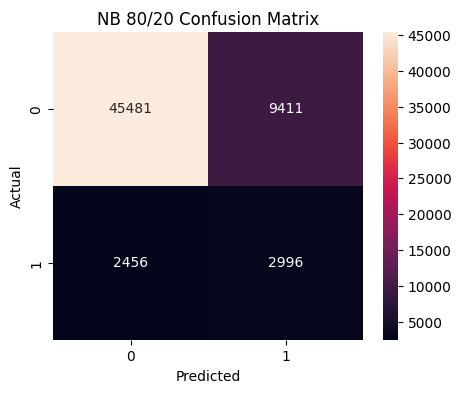

In [120]:
plot_confusion(nb_80, X_test_20_s, y_test_20, "NB 80/20 Confusion Matrix")